**COURSEWORK 2: MACHINE LEARNING**

----------------------------------------------------------------------------------------------------------------------------------------------------------------

1. Set up and prepare the environment

- Install the ucimlrepo package

In [1]:
pip install ucimlrepo

- Import the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

- Import the dataset

In [53]:
target_col = "death_event"

try:
    heart_failure_clinical_records = fetch_ucirepo(id=519)
    X = heart_failure_clinical_records.data.features
    y = heart_failure_clinical_records.data.targets[target_col].astype(np.float64)
    print("Dataset loaded from UCI.")
except Exception as e:
    print("Unable to connect to UCI, loading local dataset. Error:", e)
    df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
    y = df[target_col].astype(np.float64)
    X = df.drop(columns=[target_col])

print("Dimensions of X:", X.shape)
print("Dimensions of y:", y.shape)


Dataset loaded from UCI.
Dimensions of X: (299, 12)
Dimensions of y: (299,)


- Seperate the X (features) and Y (target)

In [54]:
target_col = "death_event"

y = df[target_col].astype(np.float64)
X = df.drop(columns=[target_col])

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print(df.head())


NameError: name 'df' is not defined

 - Split train/ val/ test (70/15/15)

In [5]:
def train_val_test_split(X, y, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=RANDOM_STATE):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8, "The ratios must be 1"

    n = len(X)
    rng = np.random.RandomState(random_state)
    indices = np.arange(n)
    rng.shuffle(indices)

    train_end = int(train_ratio * n)
    val_end   = train_end + int(val_ratio * n)

    train_idx = indices[:train_end]
    val_idx   = indices[train_end:val_end]
    test_idx  = indices[val_end:]

    X_train = X.iloc[train_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)

    X_val = X.iloc[val_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)

    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y)

print("Size train:", X_train.shape[0])
print("Size val  :", X_val.shape[0])
print("Size test :", X_test.shape[0])


Tamaño train: 209
Tamaño val  : 44
Tamaño test : 46


- Normalization (Z-score) and NumPy

In [6]:
numeric_cols = X_train.columns.tolist()

train_mean = X_train[numeric_cols].mean()
train_std  = X_train[numeric_cols].std(ddof=0)

def standardize(df, mean, std):
    std_safe = std.copy()
    std_safe[std_safe == 0] = 1.0
    return (df[numeric_cols] - mean) / std_safe

X_train_std = standardize(X_train, train_mean, train_std)
X_val_std   = standardize(X_val,   train_mean, train_std)
X_test_std  = standardize(X_test,  train_mean, train_std)

X_train_np = X_train_std.to_numpy()
X_val_np   = X_val_std.to_numpy()
X_test_np  = X_test_std.to_numpy()

y_train_np = y_train.to_numpy().reshape(-1, 1)
y_val_np   = y_val.to_numpy().reshape(-1, 1)
y_test_np  = y_test.to_numpy().reshape(-1, 1)

print("X_train_np shape:", X_train_np.shape)
print("y_train_np shape:", y_train_np.shape)


X_train_np shape: (209, 12)
y_train_np shape: (209, 1)


------------------------------------------------------------------------------------------------------------------------------------------------------------------

Part B.a

- Activation Function and Lost Function

In [7]:
def sigmoid(z):
    # Avoid overflow
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1.0 - a)

def binary_cross_entropy(y_true, y_pred, eps=1e-10):
    """
    y_true: (N,1)  con valores 0/1
    y_pred: (N,1)  con valores en (0,1)
    """
    y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
    loss = - (y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
    return np.mean(loss)

- Class Hide layer

In [52]:
class SingleLayerPerceptron:
    def __init__(self, input_dim, hidden_units=8, learning_rate=0.01):
        self.input_dim = input_dim
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate
        self._init_weights()

    def _init_weights(self):
        self.W1 = np.random.randn(self.input_dim, self.hidden_units) * 0.01
        self.b1 = np.zeros((1, self.hidden_units))
        self.W2 = np.random.randn(self.hidden_units, 1) * 0.01
        self.b2 = np.zeros((1, 1))

    def forward(self, X):
        """
        X: (N, input_dim)
        """
        Z1 = np.dot(X, self.W1) + self.b1      # (N, hidden_units)
        A1 = sigmoid(Z1)                       # activación oculta
        Z2 = np.dot(A1, self.W2) + self.b2     # (N, 1)
        A2 = sigmoid(Z2)

        cache = {
            "X": X,
            "Z1": Z1, "A1": A1,
            "Z2": Z2, "A2": A2
        }
        return A2, cache

    def backward(self, y_true, cache):
        """
        Retropropagate y update pesos with gradient descendant (batch).
        y_true: (N,1)
        """
        X  = cache["X"]
        A1 = cache["A1"]
        A2 = cache["A2"]

        N = X.shape[0]


        dZ2 = A2 - y_true                     # (N,1)
        dW2 = np.dot(A1.T, dZ2) / N           # (hidden_units,1)
        db2 = np.sum(dZ2, axis=0, keepdims=True) / N

        dA1 = np.dot(dZ2, self.W2.T)          # (N, hidden_units)
        dZ1 = dA1 * sigmoid_derivative(A1)    # (N, hidden_units)
        dW1 = np.dot(X.T, dZ1) / N            # (input_dim, hidden_units)
        db1 = np.sum(dZ1, axis=0, keepdims=True) / N


        lr = self.learning_rate
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def predict_proba(self, X):
        A2, _ = self.forward(X)
        return A2

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

    def fit(self, X_train, y_train, X_val=None, y_val=None, epochs=100):
        """
        Train the network y return the record of loss to my grahic
        """
        history = {
            "train_loss": [],
            "val_loss": []
        }

        for epoch in range(1, epochs + 1):
            # Forward en train
            y_pred_train, cache = self.forward(X_train)
            train_loss = binary_cross_entropy(y_train, y_pred_train)

            # Backprop + actualización
            self.backward(y_train, cache)

            # Guardar pérdidas
            history["train_loss"].append(train_loss)

            if X_val is not None and y_val is not None:
                y_pred_val, _ = self.forward(X_val)
                val_loss = binary_cross_entropy(y_val, y_pred_val)
                history["val_loss"].append(val_loss)
            else:
                history["val_loss"].append(None)

            # Mensajito opcional cada 20 épocas
            if epoch % 20 == 0 or epoch == 1 or epoch == epochs:
                if X_val is not None and y_val is not None:
                    print(f"Epoch {epoch:4d} - loss_train={train_loss:.4f}, loss_val={val_loss:.4f}")
                else:
                    print(f"Epoch {epoch:4d} - loss_train={train_loss:.4f}")

        return history


Part B.b

- Accuracy Calcule

In [9]:
def accuracy_score_numpy(y_true, y_pred):
    """
    y_true, y_pred: arrays (N,1) o (N,)
    """
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)
    return np.mean(y_true_flat == y_pred_flat)


- Train the perceptron

In [10]:
input_dim = X_train_np.shape[1]
hidden_units = 8
learning_rate = 0.01
epochs = 200

mlp = SingleLayerPerceptron(input_dim=input_dim,
                            hidden_units=hidden_units,
                            learning_rate=learning_rate)

history = mlp.fit(X_train_np, y_train_np,
                  X_val=X_val_np, y_val=y_val_np,
                  epochs=epochs)

y_train_pred = mlp.predict(X_train_np)
y_val_pred   = mlp.predict(X_val_np)

train_acc = accuracy_score_numpy(y_train_np, y_train_pred)
val_acc   = accuracy_score_numpy(y_val_np,   y_val_pred)

print(f"\nAccuracy TRAIN: {train_acc:.4f}")
print(f"Accuracy VAL  : {val_acc:.4f}")


Epoch    1 - loss_train=0.6911, loss_val=0.6895
Epoch   20 - loss_train=0.6796, loss_val=0.6743
Epoch   40 - loss_train=0.6706, loss_val=0.6617
Epoch   60 - loss_train=0.6638, loss_val=0.6520
Epoch   80 - loss_train=0.6588, loss_val=0.6444
Epoch  100 - loss_train=0.6550, loss_val=0.6384
Epoch  120 - loss_train=0.6522, loss_val=0.6336
Epoch  140 - loss_train=0.6500, loss_val=0.6297
Epoch  160 - loss_train=0.6484, loss_val=0.6266
Epoch  180 - loss_train=0.6471, loss_val=0.6240
Epoch  200 - loss_train=0.6461, loss_val=0.6219

Accuracy TRAIN: 0.6555
Accuracy VAL  : 0.7045


Part B.c

- Auxiliar function to test Hyperparameters

In [51]:
def run_experiment(lr=0.01, epochs=200, hidden_units=8,
                   X_train=X_train_np, y_train=y_train_np,
                   X_val=X_val_np,   y_val=y_val_np,
                   verbose=True):
    """
    Train a SingleLayerPerceptron with the Hyperparameters
    and return accuracies of train and val.
    """
    input_dim = X_train.shape[1]

    model = SingleLayerPerceptron(input_dim=input_dim,
                                  hidden_units=hidden_units,
                                  learning_rate=lr)

    history = model.fit(X_train, y_train,
                        X_val=X_val, y_val=y_val,
                        epochs=epochs)

    y_train_pred = model.predict(X_train)
    y_val_pred   = model.predict(X_val)

    train_acc = accuracy_score_numpy(y_train, y_train_pred)
    val_acc   = accuracy_score_numpy(y_val,   y_val_pred)

    if verbose:
        print(f"\n[RESULTS] lr={lr}, epochs={epochs}, hidden_units={hidden_units}")
        print(f"  Accuracy TRAIN = {train_acc:.4f}")
        print(f"  Accuracy VAL   = {val_acc:.4f}")

    return {
        "model": model,
        "history": history,
        "train_acc": train_acc,
        "val_acc": val_acc
    }


- Learning Rate Experiment

In [50]:
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
epochs = 200
hidden_units = 8

results_lr = []

for lr in learning_rates:
    print("=" * 60)
    print(f"Trying learning rate = {lr}")
    res = run_experiment(lr=lr, epochs=epochs, hidden_units=hidden_units, verbose=True)
    res["lr"] = lr
    results_lr.append(res)

print("\nSummary (lr, train_acc, val_acc):")
for r in results_lr:
    print(f"lr={r['lr']:<6}  train_acc={r['train_acc']:.4f}  val_acc={r['val_acc']:.4f}")


Trying learning rate = 0.001
Epoch    1 - loss_train=0.6923, loss_val=0.6919
Epoch   20 - loss_train=0.6909, loss_val=0.6902
Epoch   40 - loss_train=0.6896, loss_val=0.6884
Epoch   60 - loss_train=0.6882, loss_val=0.6866
Epoch   80 - loss_train=0.6870, loss_val=0.6849
Epoch  100 - loss_train=0.6857, loss_val=0.6832
Epoch  120 - loss_train=0.6845, loss_val=0.6816
Epoch  140 - loss_train=0.6833, loss_val=0.6800
Epoch  160 - loss_train=0.6822, loss_val=0.6784
Epoch  180 - loss_train=0.6811, loss_val=0.6769
Epoch  200 - loss_train=0.6800, loss_val=0.6754

[RESULTADO] lr=0.001, epochs=200, hidden_units=8
  Accuracy TRAIN = 0.6555
  Accuracy VAL   = 0.7045
Trying learning rate = 0.005
Epoch    1 - loss_train=0.6897, loss_val=0.6881
Epoch   20 - loss_train=0.6837, loss_val=0.6802
Epoch   40 - loss_train=0.6782, loss_val=0.6728
Epoch   60 - loss_train=0.6736, loss_val=0.6663
Epoch   80 - loss_train=0.6695, loss_val=0.6606
Epoch  100 - loss_train=0.6660, loss_val=0.6556
Epoch  120 - loss_train=

- Epoch number experiment

In [49]:
lr_fixed = 0.01
hidden_units = 8
epoch_values = [50, 100, 200, 400]

results_epochs = []

for ep in epoch_values:
    print("=" * 60)
    print(f"Trying epochs = {ep}")
    res = run_experiment(lr=lr_fixed, epochs=ep, hidden_units=hidden_units, verbose=True)
    res["epochs"] = ep
    results_epochs.append(res)

print("\nSummary(epochs, train_acc, val_acc):")
for r in results_epochs:
    print(f"epochs={r['epochs']:<4}  train_acc={r['train_acc']:.4f}  val_acc={r['val_acc']:.4f}")


Trying epochs = 50
Epoch    1 - loss_train=0.6960, loss_val=0.6959
Epoch   20 - loss_train=0.6833, loss_val=0.6793
Epoch   40 - loss_train=0.6733, loss_val=0.6657
Epoch   50 - loss_train=0.6693, loss_val=0.6600

[RESULTADO] lr=0.01, epochs=50, hidden_units=8
  Accuracy TRAIN = 0.6555
  Accuracy VAL   = 0.7045
Trying epochs = 100
Epoch    1 - loss_train=0.6941, loss_val=0.6934
Epoch   20 - loss_train=0.6817, loss_val=0.6771
Epoch   40 - loss_train=0.6719, loss_val=0.6638
Epoch   60 - loss_train=0.6647, loss_val=0.6534
Epoch   80 - loss_train=0.6593, loss_val=0.6453
Epoch  100 - loss_train=0.6552, loss_val=0.6390

[RESULTADO] lr=0.01, epochs=100, hidden_units=8
  Accuracy TRAIN = 0.6555
  Accuracy VAL   = 0.7045
Trying epochs = 200
Epoch    1 - loss_train=0.6974, loss_val=0.6977
Epoch   20 - loss_train=0.6843, loss_val=0.6806
Epoch   40 - loss_train=0.6739, loss_val=0.6666
Epoch   60 - loss_train=0.6663, loss_val=0.6557
Epoch   80 - loss_train=0.6605, loss_val=0.6472
Epoch  100 - loss_tr

- Experiment with size of the whole training

In [14]:
def sample_train_set(X_train, y_train, fraction, random_state=RANDOM_STATE):
    """
    Return a random sample of X_train, y_train with the indicate percentage
    fraction en (0,1].
    """
    N = X_train.shape[0]
    n_sample = int(N * fraction)

    rng = np.random.RandomState(random_state)
    indices = np.arange(N)
    rng.shuffle(indices)
    chosen = indices[:n_sample]

    return X_train[chosen], y_train[chosen]

fractions = [0.3, 0.5, 0.7, 1.0]   # 30%, 50%, 70%, 100%
lr_fixed = 0.01
epochs_fixed = 200
hidden_units = 8

results_size = []

for frac in fractions:
    print("=" * 60)
    print(f"Trying the size of train = {frac*100:.0f}%")

    X_tr_sub, y_tr_sub = sample_train_set(X_train_np, y_train_np, fraction=frac)

    res = run_experiment(lr=lr_fixed,
                         epochs=epochs_fixed,
                         hidden_units=hidden_units,
                         X_train=X_tr_sub,
                         y_train=y_tr_sub,
                         X_val=X_val_np,
                         y_val=y_val_np,
                         verbose=True)
    res["fraction"] = frac
    results_size.append(res)

print("\nSummary (fraction, train_acc, val_acc):")
for r in results_size:
    print(f"frac={r['fraction']:<4}  train_acc={r['train_acc']:.4f}  val_acc={r['val_acc']:.4f}")


Probando tamaño de train = 30%
Epoch    1 - loss_train=0.6951, loss_val=0.6945
Epoch   20 - loss_train=0.6816, loss_val=0.6775
Epoch   40 - loss_train=0.6710, loss_val=0.6637
Epoch   60 - loss_train=0.6632, loss_val=0.6530
Epoch   80 - loss_train=0.6573, loss_val=0.6446
Epoch  100 - loss_train=0.6529, loss_val=0.6381
Epoch  120 - loss_train=0.6495, loss_val=0.6329
Epoch  140 - loss_train=0.6470, loss_val=0.6288
Epoch  160 - loss_train=0.6450, loss_val=0.6255
Epoch  180 - loss_train=0.6435, loss_val=0.6228
Epoch  200 - loss_train=0.6423, loss_val=0.6206

[RESULTADO] lr=0.01, epochs=200, hidden_units=8
  Accuracy TRAIN = 0.6613
  Accuracy VAL   = 0.7045
Probando tamaño de train = 50%
Epoch    1 - loss_train=0.6900, loss_val=0.6875
Epoch   20 - loss_train=0.6816, loss_val=0.6745
Epoch   40 - loss_train=0.6751, loss_val=0.6637
Epoch   60 - loss_train=0.6702, loss_val=0.6552
Epoch   80 - loss_train=0.6666, loss_val=0.6484
Epoch  100 - loss_train=0.6638, loss_val=0.6429
Epoch  120 - loss_tra

Part B.d

- Learning Curves

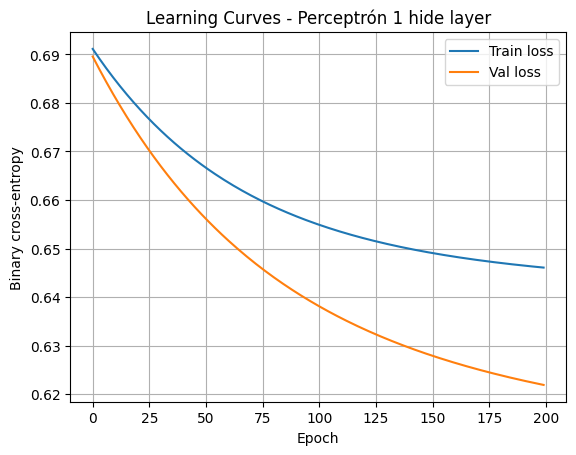

In [15]:
train_losses = history["train_loss"]
val_losses   = history["val_loss"]

plt.figure()
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Learning Curves - Perceptrón 1 hide layer")
plt.legend()
plt.grid(True)
plt.show()


- Final Learning Rate Plot

Epoch    1 - loss_train=0.6933, loss_val=0.6923
Epoch   20 - loss_train=0.6811, loss_val=0.6762
Epoch   40 - loss_train=0.6715, loss_val=0.6631
Epoch   60 - loss_train=0.6643, loss_val=0.6529
Epoch   80 - loss_train=0.6590, loss_val=0.6450
Epoch  100 - loss_train=0.6550, loss_val=0.6387
Epoch  120 - loss_train=0.6520, loss_val=0.6337
Epoch  140 - loss_train=0.6497, loss_val=0.6297
Epoch  160 - loss_train=0.6480, loss_val=0.6264
Epoch  180 - loss_train=0.6466, loss_val=0.6238
Epoch  200 - loss_train=0.6455, loss_val=0.6216


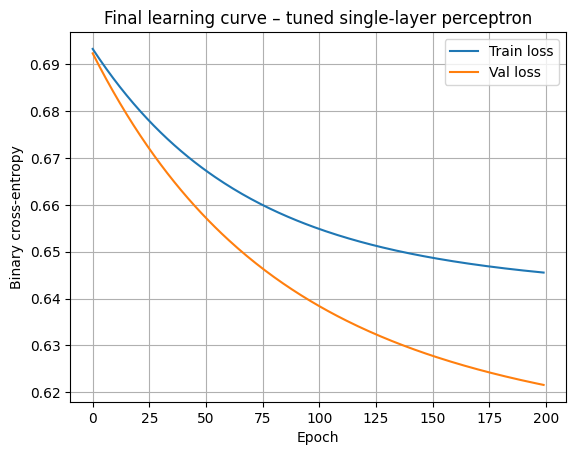

In [17]:
best_lr = 0.01
best_hidden_units = 8
best_epochs = 200

input_dim = X_train_np.shape[1]

mlp_best = SingleLayerPerceptron(
    input_dim=input_dim,
    hidden_units=best_hidden_units,
    learning_rate=best_lr
)

history_best = mlp_best.fit(
    X_train_np, y_train_np,
    X_val=X_val_np, y_val=y_val_np,
    epochs=best_epochs
)

train_losses_best = history_best["train_loss"]
val_losses_best   = history_best["val_loss"]

plt.figure()
plt.plot(train_losses_best, label="Train loss")
plt.plot(val_losses_best,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Final learning curve – tuned single-layer perceptron")
plt.legend()
plt.grid(True)
plt.show()


------------------------------------------------------------------------------

Part C.a

- Deeper Network

In [48]:
class MultiLayerPerceptron:
    def __init__(self, input_dim, hidden_layers, learning_rate=0.01):
        """
        input_dim: nº de features de entrada
        hidden_layers: lista con nº de neuronas por capa oculta, ej [8, 8] o [16, 8, 4]
        """
        self.input_dim = input_dim
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        self._init_weights()

    def _init_weights(self):
        layer_sizes = [self.input_dim] + self.hidden_layers + [1]
        self.W = []
        self.b = []

        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
            b = np.zeros((1, layer_sizes[i+1]))
            self.W.append(w)
            self.b.append(b)

    def forward(self, X):
        """
        Propagate onward in every layer.
        Return the output and a 'cache' with the all intermediates
        """
        A = X
        As = [X]
        Zs = []

        for W, b in zip(self.W, self.b):
            Z = np.dot(A, W) + b
            A = sigmoid(Z)
            Zs.append(Z)
            As.append(A)

        cache = {
            "As": As,
            "Zs": Zs,
            "X": X
        }
        return As[-1], cache

    def backward(self, y_true, cache):
        """
        Backprop for every layer and update for gradient descendant (batch).
        """
        As = cache["As"]
        Zs = cache["Zs"]
        N = y_true.shape[0]

        dW = [None] * len(self.W)
        db = [None] * len(self.b)

        A_L = As[-1]
        dZ = A_L - y_true

        for l in reversed(range(len(self.W))):
            A_prev = As[l]

            dW[l] = np.dot(A_prev.T, dZ) / N
            db[l] = np.sum(dZ, axis=0, keepdims=True) / N

            if l != 0:
                dA_prev = np.dot(dZ, self.W[l].T)
                A_l = As[l]
                dZ = dA_prev * sigmoid_derivative(A_l)

        lr = self.learning_rate
        for l in range(len(self.W)):
            self.W[l] -= lr * dW[l]
            self.b[l] -= lr * db[l]

    def predict_proba(self, X):
        A_L, _ = self.forward(X)
        return A_L

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

    def fit(self, X_train, y_train, X_val=None, y_val=None, epochs=100, verbose=False):
        """
        Train the Whole Network.
        Return the Record of Loss to may grahic
        """
        history = {"train_loss": [], "val_loss": []}

        for epoch in range(1, epochs + 1):
            y_pred_train, cache = self.forward(X_train)
            train_loss = binary_cross_entropy(y_train, y_pred_train)

            self.backward(y_train, cache)

            history["train_loss"].append(train_loss)

            if X_val is not None and y_val is not None:
                y_pred_val, _ = self.forward(X_val)
                val_loss = binary_cross_entropy(y_val, y_pred_val)
                history["val_loss"].append(val_loss)
            else:
                history["val_loss"].append(None)

            if verbose and (epoch == 1 or epoch % 20 == 0 or epoch == epochs):
                if X_val is not None and y_val is not None:
                    print(f"Epoch {epoch:4d} - loss_train={train_loss:.4f}, loss_val={val_loss:.4f}")
                else:
                    print(f"Epoch {epoch:4d} - loss_train={train_loss:.4f}")

        return history


- Define the 3 Arquitecture (2, 4 and 6 layers)

In [47]:
input_dim = X_train_np.shape[1]

arch_2_layers = [16, 8]
arch_4_layers = [32, 16, 8, 4]
arch_6_layers = [64, 32, 16, 8, 4, 2]

print("Architecture 2 hidden layer :", arch_2_layers)
print("Architecture 4 hidden layer :", arch_4_layers)
print("Architecture 6 hidden layer :", arch_6_layers)


Architecture 2 hidden layer : [16, 8]
Architecture 4 hidden layer : [32, 16, 8, 4]
Architecture 6 hidden layer : [64, 32, 16, 8, 4, 2]


Part C (Cross-Validation)

In [46]:
def create_k_folds(X, y, k=10, random_state=RANDOM_STATE):
    N = X.shape[0]
    rng = np.random.RandomState(random_state)
    indices = np.arange(N)
    rng.shuffle(indices)

    folds = []
    fold_sizes = [N // k] * k
    for i in range(N % k):
        fold_sizes[i] += 1

    current = 0
    for fold_size in fold_sizes:
        start, end = current, current + fold_size
        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])
        folds.append((train_idx, val_idx))
        current = end

    return folds

folds_10 = create_k_folds(X_train_np, y_train_np, k=10)
print(f"Number of folds created: {len(folds_10)}")
print("Example fold 0 (Sizes):",
      folds_10[0][0].shape[0], "train,",
      folds_10[0][1].shape[0], "val")


Number of folds created: 10
Example fold 0 (Sizes): 188 train, 21 val


Part C.b

- Effect of layers number and neurons

In [44]:
def run_cv_for_architecture(hidden_layers, folds,
                            lr=0.01, epochs=200, verbose=False):
    """
    hidden_layers: list, ej [16,8]
    folds: lists of (train_idx, val_idx) created for create_k_folds
    """
    train_accs = []
    val_accs = []

    for i, (train_idx, val_idx) in enumerate(folds):
        X_tr = X_train_np[train_idx]
        y_tr = y_train_np[train_idx]
        X_val_cv = X_train_np[val_idx]
        y_val_cv = y_train_np[val_idx]

        model = MultiLayerPerceptron(input_dim=X_tr.shape[1],
                                     hidden_layers=hidden_layers,
                                     learning_rate=lr)

        history = model.fit(X_tr, y_tr,
                            X_val=X_val_cv, y_val=y_val_cv,
                            epochs=epochs,
                            verbose=False)

        y_tr_pred = model.predict(X_tr)
        y_val_pred = model.predict(X_val_cv)

        train_acc = accuracy_score_numpy(y_tr, y_tr_pred)
        val_acc = accuracy_score_numpy(y_val_cv, y_val_pred)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if verbose:
            print(f"Fold {i}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    mean_train = np.mean(train_accs)
    mean_val = np.mean(val_accs)

    print("\nArchitecture:", hidden_layers)
    print(f"Average accuracy TRAIN (10-fold): {mean_train:.4f}")
    print(f"Average Accuracy VAL  (10-fold): {mean_val:.4f}")

    return {
        "hidden_layers": hidden_layers,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "mean_train_acc": mean_train,
        "mean_val_acc": mean_val
    }


- Compare the Arquitecture 2, 4 and 6 layers

In [43]:
lr_cv = 0.01
epochs_cv = 200

print("-> Architecture with two hidden layers")
res_arch2 = run_cv_for_architecture(arch_2_layers, folds_10, lr=lr_cv, epochs=epochs_cv)

print("\n->Architecture with four hidden layers")
res_arch4 = run_cv_for_architecture(arch_4_layers, folds_10, lr=lr_cv, epochs=epochs_cv)

print("\n->Architecture with six hidden layers")
res_arch6 = run_cv_for_architecture(arch_6_layers, folds_10, lr=lr_cv, epochs=epochs_cv)

-> Architecture with two hidden layers

Arquitectura: [16, 8]
Accuracy medio TRAIN (10-fold): 0.6555
Accuracy medio VAL   (10-fold): 0.6555

->Architecture with four hidden layers

Arquitectura: [32, 16, 8, 4]
Accuracy medio TRAIN (10-fold): 0.6555
Accuracy medio VAL   (10-fold): 0.6555

->Architecture with six hidden layers

Arquitectura: [64, 32, 16, 8, 4, 2]
Accuracy medio TRAIN (10-fold): 0.6555
Accuracy medio VAL   (10-fold): 0.6555


Part C.c

- Error curve for each arquitecture


Learning Architecture [16, 8]


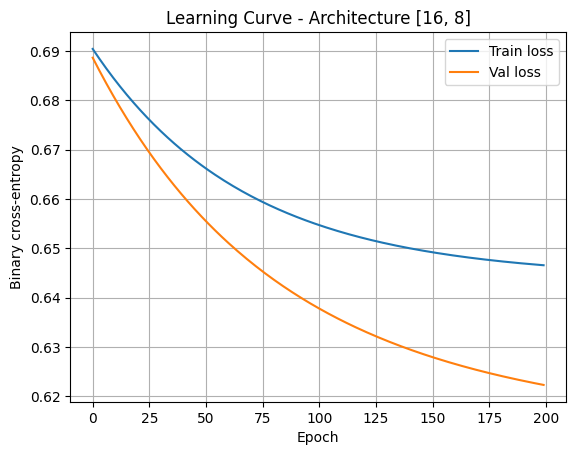


Learning Architecture [32, 16, 8, 4]


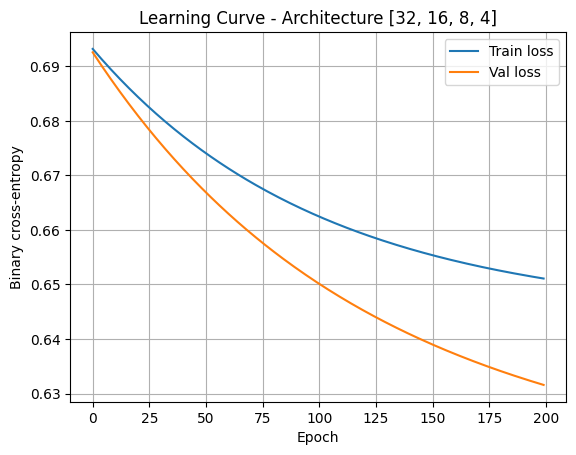


Learning Architecture [64, 32, 16, 8, 4, 2]


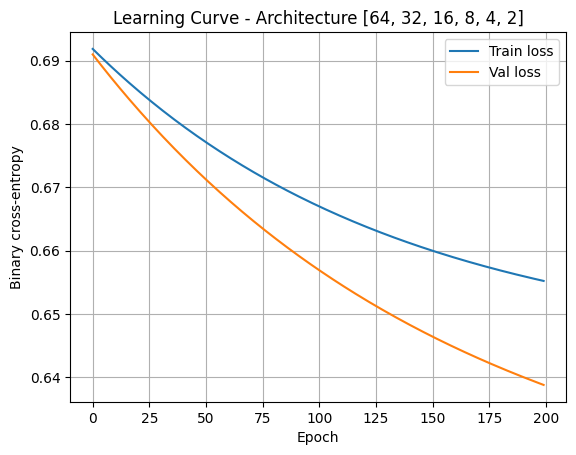

In [25]:
def train_and_plot_architecture(hidden_layers, lr=0.01, epochs=200):
    print(f"\nLearning Architecture {hidden_layers}")
    model = MultiLayerPerceptron(input_dim=X_train_np.shape[1],
                                 hidden_layers=hidden_layers,
                                 learning_rate=lr)
    history = model.fit(X_train_np, y_train_np,
                        X_val=X_val_np, y_val=y_val_np,
                        epochs=epochs,
                        verbose=False)

    train_losses = history["train_loss"]
    val_losses = history["val_loss"]

    plt.figure()
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.title(f"Learning Curve - Architecture {hidden_layers}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, history

epochs_plot = 200
lr_plot = 0.01

model2, hist2 = train_and_plot_architecture(arch_2_layers, lr=lr_plot, epochs=epochs_plot)
model4, hist4 = train_and_plot_architecture(arch_4_layers, lr=lr_plot, epochs=epochs_plot)
model6, hist6 = train_and_plot_architecture(arch_6_layers, lr=lr_plot, epochs=epochs_plot)

Part C.d

- Choose the best Hyperparameters

In [41]:
all_results = [res_arch2, res_arch4, res_arch6]

print("Summary of average accuracies (10-fold):\n")
for r in all_results:
    print(f"Architecture {r['hidden_layers']}: "
          f"mean_train_acc={r['mean_train_acc']:.4f}, "
          f"mean_val_acc={r['mean_val_acc']:.4f}")

# Choose the better
best_result = max(all_results, key=lambda r: r["mean_val_acc"])
best_arch = best_result["hidden_layers"]

print("\nBEST ARCHITECTURE ACCORDING TO 10-FOLD (VAL):", best_arch)


Summary of average accuracies (10-fold):

Architecture [16, 8]: mean_train_acc=0.6555, mean_val_acc=0.6555
Architecture [32, 16, 8, 4]: mean_train_acc=0.6555, mean_val_acc=0.6555
Architecture [64, 32, 16, 8, 4, 2]: mean_train_acc=0.6555, mean_val_acc=0.6555

BEST ARCHITECTURE ACCORDING TO 10-FOLD (VAL): [16, 8]


Part C.e

- Experiment the size of train with the best arquitecture

In [40]:
def sample_train_set_np(X_train, y_train, fraction, random_state=RANDOM_STATE):
    N = X_train.shape[0]
    n_sample = int(N * fraction)
    rng = np.random.RandomState(random_state)
    indices = np.arange(N)
    rng.shuffle(indices)
    chosen = indices[:n_sample]
    return X_train[chosen], y_train[chosen]

fractions_ce = [0.3, 0.5, 0.7, 1.0]  # 30%, 50%, 70%, 100%

results_ce = []

for frac in fractions_ce:
    print("=" * 60)
    print(f"Trying fraction={frac*100:.0f}% of the train, architecture {best_arch}")

    X_tr_sub, y_tr_sub = sample_train_set_np(X_train_np, y_train_np, fraction=frac)

    model = MultiLayerPerceptron(input_dim=X_tr_sub.shape[1],
                                 hidden_layers=best_arch,
                                 learning_rate=lr_cv)

    history = model.fit(X_tr_sub, y_tr_sub,
                        X_val=X_val_np, y_val=y_val_np,
                        epochs=epochs_cv,
                        verbose=False)

    y_tr_pred = model.predict(X_tr_sub)
    y_val_pred = model.predict(X_val_np)

    train_acc = accuracy_score_numpy(y_tr_sub, y_tr_pred)
    val_acc   = accuracy_score_numpy(y_val_np, y_val_pred)

    print(f"Accuracy TRAIN = {train_acc:.4f}")
    print(f"Accuracy VAL   = {val_acc:.4f}")

    results_ce.append({
        "fraction": frac,
        "train_acc": train_acc,
        "val_acc": val_acc
    })

print("\nSummary fraction/train_acc/val_acc:")
for r in results_ce:
    print(f"frac={r['fraction']:<4}  train_acc={r['train_acc']:.4f}  val_acc={r['val_acc']:.4f}")


Trying fraction=30% of the train, architecture [16, 8]
Accuracy TRAIN = 0.6613
Accuracy VAL   = 0.7045
Trying fraction=50% of the train, architecture [16, 8]
Accuracy TRAIN = 0.6346
Accuracy VAL   = 0.7045
Trying fraction=70% of the train, architecture [16, 8]
Accuracy TRAIN = 0.6370
Accuracy VAL   = 0.7045
Trying fraction=100% of the train, architecture [16, 8]
Accuracy TRAIN = 0.6555
Accuracy VAL   = 0.7045

Summary fraction/train_acc/val_acc:
frac=0.3   train_acc=0.6613  val_acc=0.7045
frac=0.5   train_acc=0.6346  val_acc=0.7045
frac=0.7   train_acc=0.6370  val_acc=0.7045
frac=1.0   train_acc=0.6555  val_acc=0.7045


Part C.f

- Add method fit_batch to MultiLayerPerceptron

In [39]:
def fit_batch(self, X_train, y_train, X_val=None, y_val=None, epochs=100, verbose=False):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):

        y_pred_train, cache = self.forward(X_train)
        train_loss = binary_cross_entropy(y_train, y_pred_train)

        self.backward(y_train, cache)
        history["train_loss"].append(train_loss)

        if X_val is not None and y_val is not None:
            y_pred_val, _ = self.forward(X_val)
            val_loss = binary_cross_entropy(y_val, y_pred_val)
            history["val_loss"].append(val_loss)
        else:
            history["val_loss"].append(None)

        if verbose and (epoch == 1 or epoch % 20 == 0 or epoch == epochs):
            if X_val is not None and y_val is not None:
                print(f"[BATCH] Epoch {epoch:4d} - loss_train={train_loss:.4f}, loss_val={val_loss:.4f}")
            else:
                print(f"[BATCH] Epoch {epoch:4d} - loss_train={train_loss:.4f}")

    return history

setattr(MultiLayerPerceptron, "fit_batch", fit_batch)

Part C.g

- Matrix confusion function

In [37]:
def confusion_matrix_binary(y_true, y_pred):
    """
    y_true, y_pred: arrays (N,1) o (N,)
    Return (tn, fp, fn, tp)
    """
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return tn, fp, fn, tp

def print_confusion_matrix(tn, fp, fn, tp):
    print("Confusion matrix (binary):")
    print("                 Foretold 0     Foretold 1")
    print(f"Real 0 (neg)     {tn:5d}         {fp:5d}")
    print(f"Real 1 (pos)     {fn:5d}         {tp:5d}")


- Train the best model with Batch and evaluate in test

In [38]:
best_model = MultiLayerPerceptron(input_dim=X_train_np.shape[1],
                                  hidden_layers=best_arch,
                                  learning_rate=lr_cv)

print("Training a better model (batch-gradient) with architecture:", best_arch)
history_best = best_model.fit_batch(X_train_np, y_train_np,
                                    X_val=X_val_np, y_val=y_val_np,
                                    epochs=epochs_cv,
                                    verbose=True)

y_tr_pred = best_model.predict(X_train_np)
y_val_pred = best_model.predict(X_val_np)
y_te_pred = best_model.predict(X_test_np)

train_acc_best = accuracy_score_numpy(y_train_np, y_tr_pred)
val_acc_best   = accuracy_score_numpy(y_val_np,   y_val_pred)
test_acc_best  = accuracy_score_numpy(y_test_np,  y_te_pred)

print("\nFinal performance of the best model")
print(f"Accuracy TRAIN: {train_acc_best:.4f}")
print(f"Accuracy VAL  : {val_acc_best:.4f}")
print(f"Accuracy TEST : {test_acc_best:.4f}")

tn, fp, fn, tp = confusion_matrix_binary(y_test_np, y_te_pred)
print()
print_confusion_matrix(tn, fp, fn, tp)


Training a better model (batch-gradient) with architecture: [16, 8]
[BATCH] Epoch    1 - loss_train=0.6887, loss_val=0.6864
[BATCH] Epoch   20 - loss_train=0.6778, loss_val=0.6718
[BATCH] Epoch   40 - loss_train=0.6692, loss_val=0.6598
[BATCH] Epoch   60 - loss_train=0.6628, loss_val=0.6506
[BATCH] Epoch   80 - loss_train=0.6581, loss_val=0.6433
[BATCH] Epoch  100 - loss_train=0.6545, loss_val=0.6375
[BATCH] Epoch  120 - loss_train=0.6519, loss_val=0.6330
[BATCH] Epoch  140 - loss_train=0.6499, loss_val=0.6294
[BATCH] Epoch  160 - loss_train=0.6485, loss_val=0.6265
[BATCH] Epoch  180 - loss_train=0.6473, loss_val=0.6241
[BATCH] Epoch  200 - loss_train=0.6465, loss_val=0.6222

Final performance of the best model
Accuracy TRAIN: 0.6555
Accuracy VAL  : 0.7045
Accuracy TEST : 0.7609

Confusion matrix (binary):
                 Foretold 0     Foretold 1
Real 0 (neg)        35             0
Real 1 (pos)        11             0


- Heatmap of Matrix Confusion

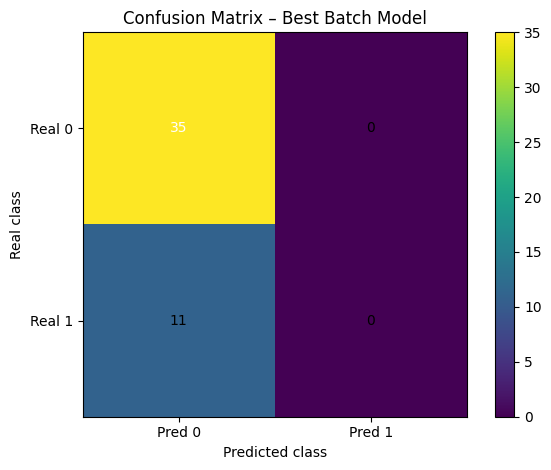

In [31]:
cm = np.array([[tn, fp],
               [fn, tp]])

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix – Best Batch Model")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Pred 0", "Pred 1"])
plt.yticks(tick_marks, ["Real 0", "Real 1"])

# Etiquetas en las casillas
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("Real class")
plt.xlabel("Predicted class")
plt.tight_layout()
plt.show()
